In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo
sns.set_theme(style="whitegrid")

# Cargar las tablas de la carpeta correcta
df_medidas = pd.read_parquet('data/processed/medidas_version.parquet')
df_transiciones = pd.read_parquet('data/processed/transiciones.parquet')
df_archivo = pd.read_parquet('data/processed/agregacion_archivo.parquet')
df_mes = pd.read_parquet('data/processed/agregacion_mes.parquet')

print("✅ Datos cargados:")
print(f"- Resúmenes únicos por archivo: {len(df_archivo)} observaciones válidas (usado en Secciones 2 y 4).")
print(f"- Agrupaciones por archivo y mes: {len(df_mes)} observaciones válidas (usado en Sección 3).")

✅ Datos cargados:
- Resúmenes únicos por archivo: 406 observaciones válidas (usado en Secciones 2 y 4).
- Agrupaciones por archivo y mes: 768 observaciones válidas (usado en Sección 3).


### 2. Comparación entre la primera y la última versión
A continuación, comparamos la longitud del body (en cantidad de palabras) entre la versión inicial y la final de cada archivo. Se utilizan historias con al menos dos versiones.

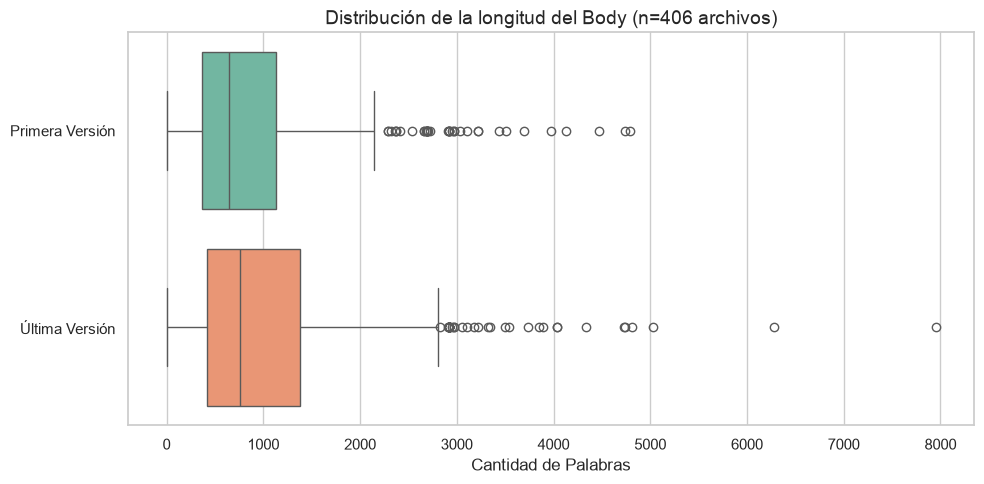


--- Estadísticas Descriptivas ---


,count,mediana,25%,75%,IQR
longitud_inicial,406.0,641.0,364.50,1132.50,768.0
longitud_final,406.0,760.0,414.75,1375.75,961.0



--- Resumen de Cambios Netos ---
Aumentaron su longitud: 222 archivos (54.7%)
Disminuyeron su longitud: 52 archivos (12.8%)
Permanecieron igual: 132 archivos (32.5%)


In [ ]:
# 1. Filtrar datos válidos (archivos que tienen longitud inicial y final que no sean nulos)
df_comp = df_archivo.dropna(subset=['longitud_inicial', 'longitud_final']).copy()
num_observaciones = len(df_comp)

# 2. Preparar los datos para Seaborn (formato largo)
df_melted = df_comp.melt(
    id_vars=['source_markdown_file_history_id'], 
    value_vars=['longitud_inicial', 'longitud_final'],
    var_name='Momento', 
    value_name='Palabras'
)
df_melted['Momento'] = df_melted['Momento'].replace({'longitud_inicial': 'Primera Versión', 'longitud_final': 'Última Versión'})

# 3. Construir el gráfico con 2 boxplots
plt.figure(figsize=(10, 5))
ax = sns.boxplot(x='Palabras', y='Momento', data=df_melted, hue='Momento', legend=False, palette='Set2')
plt.title(f'Distribución de la longitud del Body (n={num_observaciones} archivos)', fontsize=14)
plt.xlabel('Cantidad de Palabras')
plt.ylabel('')
plt.tight_layout()
plt.show()

# 4. Tabla de estadísticas (Cuartiles e IQR)
stats = df_comp[['longitud_inicial', 'longitud_final']].describe().T
stats['IQR'] = stats['75%'] - stats['25%']
print("\n--- Estadísticas Descriptivas ---")
display(stats[['count', '50%', '25%', '75%', 'IQR']].rename(columns={'50%': 'mediana'}))

# 5. Porcentajes de cambio
aumentaron = (df_comp['cambio_neto_longitud'] > 0).sum()
disminuyeron = (df_comp['cambio_neto_longitud'] < 0).sum()
iguales = (df_comp['cambio_neto_longitud'] == 0).sum()

print("\n--- Resumen de Cambios Netos ---")
print(f"Aumentaron su longitud: {aumentaron} archivos ({aumentaron/num_observaciones*100:.1f}%)")
print(f"Disminuyeron su longitud: {disminuyeron} archivos ({disminuyeron/num_observaciones*100:.1f}%)")
print(f"Permanecieron igual: {iguales} archivos ({iguales/num_observaciones*100:.1f}%)")

### 3. Evolución mensual de los cambios
En esta sección analizamos cómo varía la magnitud de los cambios realizados en los archivos a lo largo del tiempo. Utilizamos los datos agrupados por mes para observar si las modificaciones tienden a ser más invasivas (muchas palabras cambiadas) o más sutiles en distintos períodos del año.

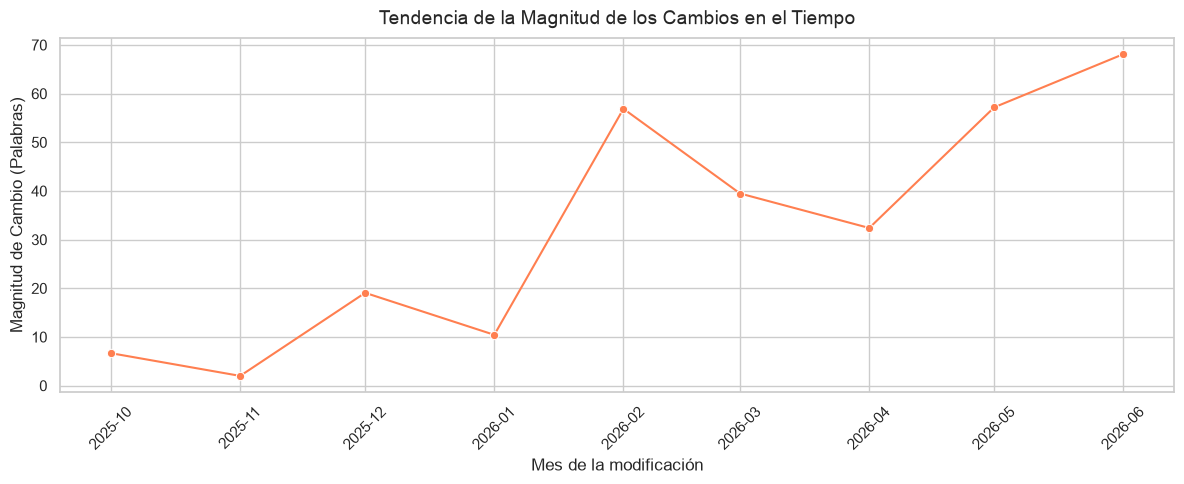

--- Top 5 meses con las modificaciones más grandes (Mediana de palabras) ---


,Mes,Magnitud Mediana
0,2025-12-01,11.50
1,2026-02-01,9.75
2,2025-10-01,4.00
3,2026-03-01,1.00
4,2025-11-01,0.00


In [8]:
# 1. Crear el gráfico de línea temporal
plt.figure(figsize=(12, 5))

# Usamos lineplot para ver la tendencia a lo largo de los meses
sns.lineplot(
    data=df_mes,
    x='mes',
    y='mediana_magnitud_cambio',
    marker='o',
    color='coral',
    errorbar=None # Ocultamos el intervalo estadístico para una lectura más limpia
)

plt.title('Tendencia de la Magnitud de los Cambios en el Tiempo', fontsize=14, pad=10)
plt.xlabel('Mes de la modificación', fontsize=12)
plt.ylabel('Magnitud de Cambio (Palabras)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Resumen de los meses con los cambios más drásticos
meses_top = df_mes.groupby('mes')['mediana_magnitud_cambio'].median().sort_values(ascending=False).head(5)
print("--- Top 5 meses con las modificaciones más grandes (Mediana de palabras) ---")
display(meses_top.reset_index().rename(columns={'mes': 'Mes', 'mediana_magnitud_cambio': 'Magnitud Mediana'}))

### 4. Tiempo transcurrido entre versiones
Finalmente, analizamos con qué frecuencia se actualizan estos flujos de trabajo. Para evitar sesgos causados por archivos con historiales anormalmente largos, calculamos primero la mediana de días entre versiones para cada archivo, y luego visualizamos la distribución global de esas medianas.

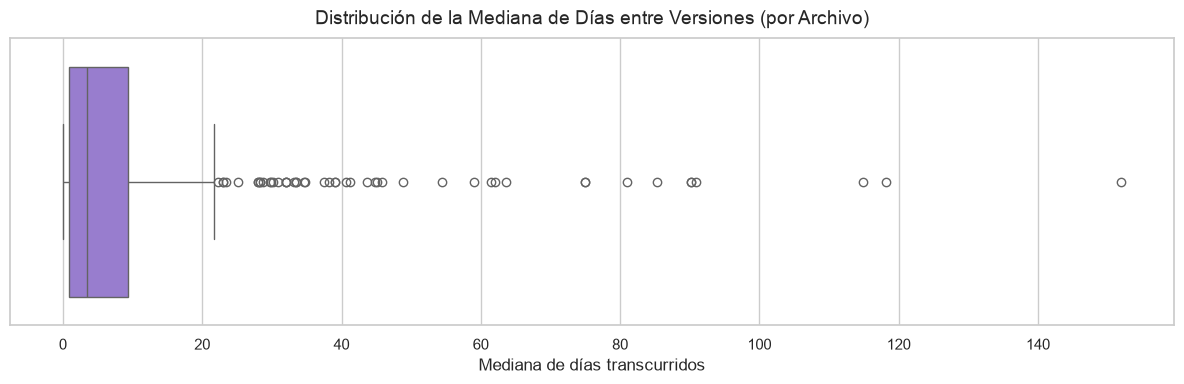

--- Estadísticas del Tiempo de Actualización (en Días) ---


,count,mean,std,min,25%,mediana,75%,max
mediana_tiempo_entre_versiones,406.0,9.808918,18.171791,0.000903,0.824074,3.447164,9.329479,151.929051


In [9]:
# 1. Filtrar valores nulos por si algún archivo no pudo calcular su tiempo
df_tiempo = df_archivo.dropna(subset=['mediana_tiempo_entre_versiones']).copy()

# 2. Crear el Boxplot
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_tiempo['mediana_tiempo_entre_versiones'], color='mediumpurple')

plt.title('Distribución de la Mediana de Días entre Versiones (por Archivo)', fontsize=14, pad=10)
plt.xlabel('Mediana de días transcurridos', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Mostrar estadísticas descriptivas finales
print("--- Estadísticas del Tiempo de Actualización (en Días) ---")
display(df_tiempo['mediana_tiempo_entre_versiones'].describe().to_frame().T.rename(columns={'50%': 'mediana'}))

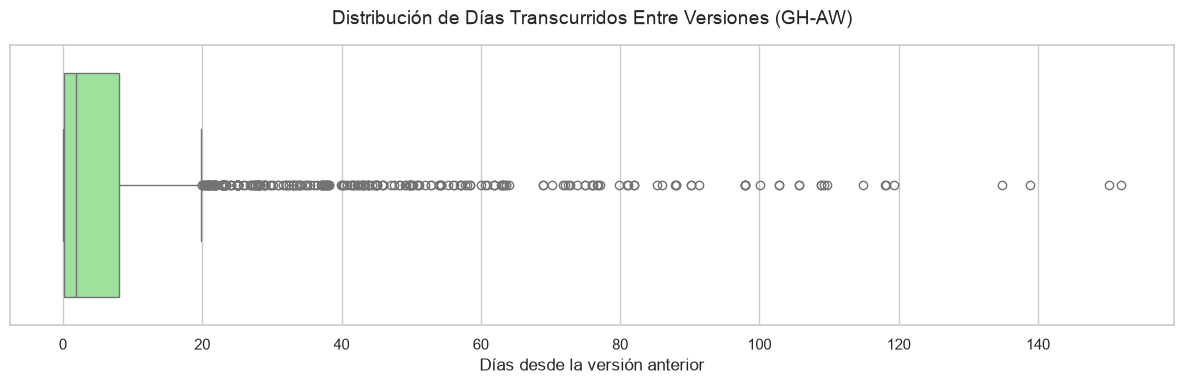

Estadísticas descriptivas del tiempo entre versiones (en días):


count    2216.000000
mean        8.671526
std        17.444189
min         0.000197
25%         0.129468
50%         1.916638
75%         8.045775
max       151.929051
Name: dias_desde_anterior, dtype: float64

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset preparado
df = pd.read_parquet('dataset_evolucion_preparado.parquet')

# 2. Eliminar los registros NaN (las versiones iniciales que no tienen tiempo previo)
df_plot = df.dropna(subset=['dias_desde_anterior'])

# 3. Configurar el tamaño y estilo del gráfico
plt.figure(figsize=(12, 4))
sns.set_theme(style="whitegrid")

# 4. Crear el Boxplot
# Nota: Los tiempos en repositorios pueden variar desde segundos hasta meses.
# Haremos un boxplot estándar para ver la distribución general.
sns.boxplot(x=df_plot['dias_desde_anterior'], color='lightgreen')

# 5. Personalizar títulos y etiquetas
plt.title('Distribución de Días Transcurridos Entre Versiones (GH-AW)', fontsize=14, pad=15)
plt.xlabel('Días desde la versión anterior', fontsize=12)

# 6. Mostrar el gráfico
plt.tight_layout()
plt.show()

# 7. Mostrar estadísticas descriptivas para complementar el gráfico
print("Estadísticas descriptivas del tiempo entre versiones (en días):")
display(df_plot['dias_desde_anterior'].describe())